In [1]:
import os
import glob
import numpy as np
import xarray as xr
import pandas as pd
import cartopy.crs as ccrs
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import matplotlib.path as mpath
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

/glade/work/turuncu/ML/envs/aurora/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
data_path = "/glade/derecho/scratch/turuncu/data/Run_global/postprocessed"

months = {
    "JAN": 1,
    "APR": 4,
    "JUL": 7,
    "OCT": 10
}

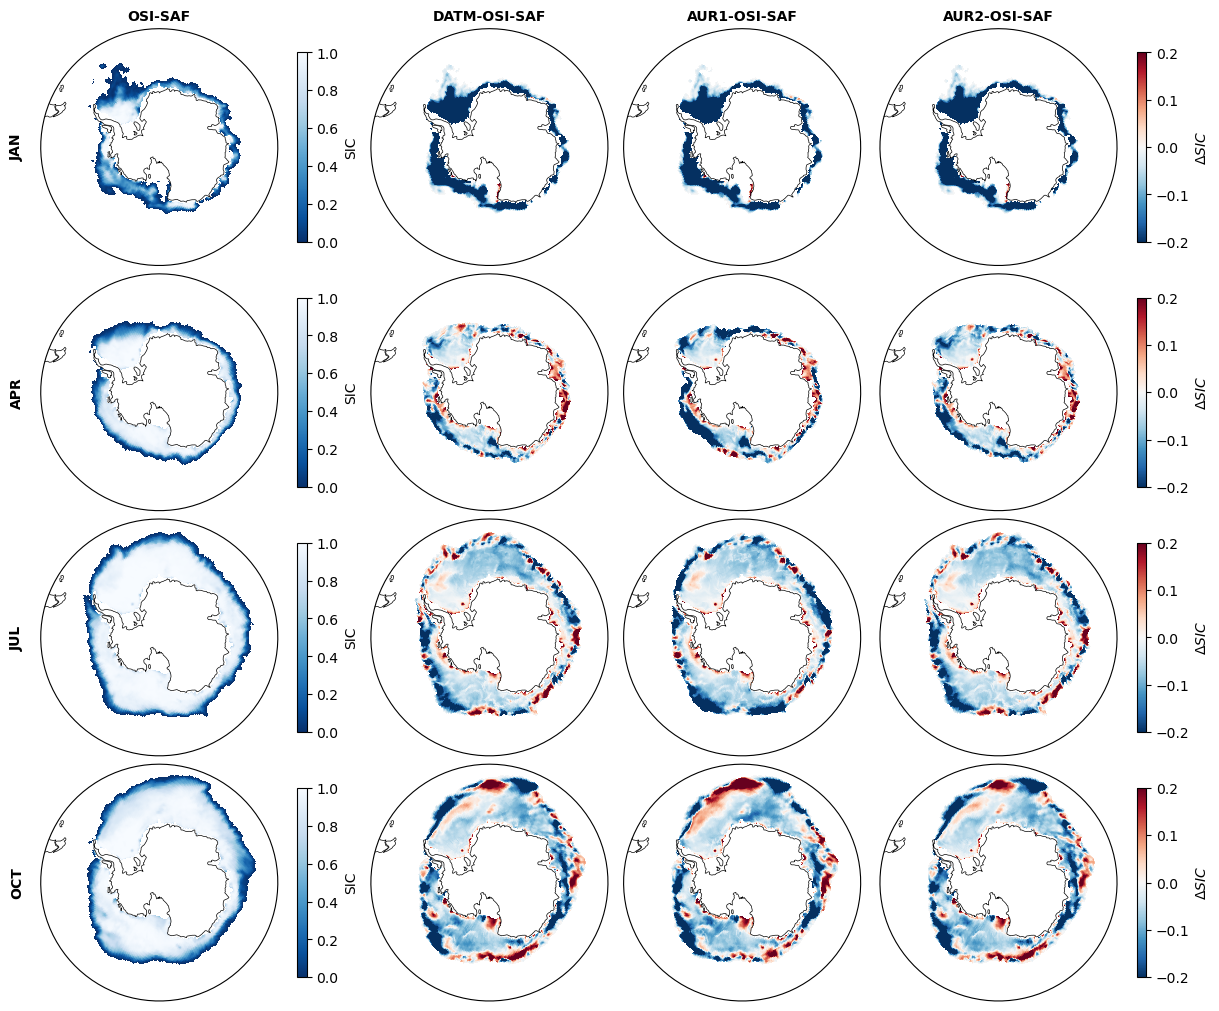

In [3]:
thold = 0.001

# Make circular boundary for polar stereographic circular plots
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# Create figure
proj  = ccrs.SouthPolarStereo()
fig, ax = plt.subplots(4, 4, figsize=(12, 10), layout='constrained', subplot_kw={'projection': proj})

irow = 0
for label, val in months.items():
    # Load datasets
    ds_ice_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_seaice/seaice_S_35d_remap_bil_tmean.nc"))
    ds_datm_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_datm/ice_merged_35d_remap_bil_tmean.nc"))
    ds_aur1_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_r2/ice_merged_35d_remap_bil_tmean.nc"))
    ds_aur2_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_two_way/ice_merged_35d_remap_bil_tmean.nc"))

    # OSISAF
    data_osisaf = ds_ice_mean.ice_conc.isel(time=0)
    data_osisaf = data_osisaf/100
    data_osisaf = data_osisaf.where(data_osisaf > thold)
    im0 = data_osisaf.plot(ax=ax[irow,0], transform=ccrs.PlateCarree(), vmin=0, vmax=1, cmap='Blues_r', add_colorbar=False)
    ax[irow,0].coastlines(linewidth=0.5)
    ax[irow,0].set_boundary(circle, transform=ax[irow,0].transAxes)
    ax[irow,0].set_extent([-180, 180, -50, -90], ccrs.PlateCarree())
    fig.colorbar(im0, ax=ax[irow,0], pad=0.08, aspect=20, shrink=0.8, label='SIC')

    # DATM
    data_datm_sh = ds_datm_mean.aice_d.isel(time=0)
    data_datm_sh = data_datm_sh.where(data_datm_sh > thold)
    data_datm_sh_diff = data_datm_sh-data_osisaf
    im1 = data_datm_sh_diff.plot(ax=ax[irow,1], transform=ccrs.PlateCarree(), vmin=-0.2, vmax=0.2, cmap='RdBu_r', add_colorbar=False)
    ax[irow,1].coastlines(linewidth=0.5)
    ax[irow,1].set_boundary(circle, transform=ax[irow,1].transAxes)
    ax[irow,1].set_extent([-180, 180, -50, -90], ccrs.PlateCarree())

    # AURORA 1W
    data_aur1_sh = ds_aur1_mean.aice_d.isel(time=0)
    data_aur1_sh = data_aur1_sh.where(data_aur1_sh > thold)
    data_aur1_sh_diff = data_aur1_sh-data_osisaf
    im2 = data_aur1_sh_diff.plot(ax=ax[irow,2], transform=ccrs.PlateCarree(), vmin=-0.2, vmax=0.2, cmap='RdBu_r', add_colorbar=False)
    ax[irow,2].coastlines(linewidth=0.5)
    ax[irow,2].set_boundary(circle, transform=ax[irow,2].transAxes)
    ax[irow,2].set_extent([-180, 180, -50, -90], ccrs.PlateCarree())

    # AURORA 2W
    data_aur2_sh = ds_aur2_mean.aice_d.isel(time=0)
    data_aur2_sh = data_aur2_sh.where(data_aur2_sh > thold)
    data_aur2_sh_diff = data_aur2_sh-data_osisaf
    im3 = data_aur2_sh_diff.plot(ax=ax[irow,3], transform=ccrs.PlateCarree(), vmin=-0.2, vmax=0.2, cmap='RdBu_r', add_colorbar=False)
    ax[irow,3].coastlines(linewidth=0.5)
    ax[irow,3].set_boundary(circle, transform=ax[irow,3].transAxes)
    ax[irow,3].set_extent([-180, 180, -50, -90], ccrs.PlateCarree())
    fig.colorbar(im3, ax=ax[irow,3], pad=0.08, aspect=20, shrink=0.8, label=r'$\Delta SIC$')

    # Labels
    if irow == 0:
        ax[irow,0].set_title("OSI-SAF", fontweight='bold', fontsize=10)
        ax[irow,1].set_title("DATM-OSI-SAF", fontweight='bold', fontsize=10)
        ax[irow,2].set_title("AUR1-OSI-SAF", fontweight='bold', fontsize=10)
        ax[irow,3].set_title("AUR2-OSI-SAF", fontweight='bold', fontsize=10)
    else:
        ax[irow,0].set_title("")
        ax[irow,1].set_title("")
        ax[irow,2].set_title("")
        ax[irow,3].set_title("")

    ax[irow,0].text(-0.1, 0.5, f"{label}", transform=ax[irow,0].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

    irow = irow+1

# Save to file
filename = "s2s_sic_SH.png"
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)

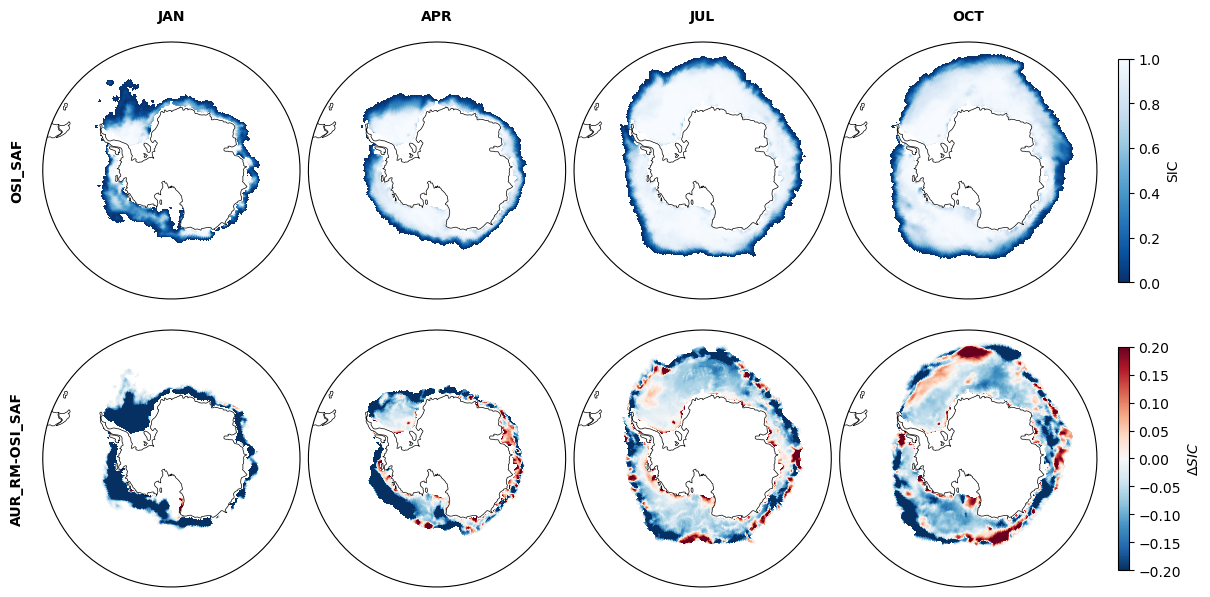

In [3]:
thold = 0.001

# Make circular boundary for polar stereographic circular plots
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# Create figure
proj  = ccrs.SouthPolarStereo()
fig, ax = plt.subplots(2, 4, figsize=(12, 6), layout='constrained', subplot_kw={'projection': proj})

icol = 0
for label, val in months.items():
    # Load datasets
    ds_ice_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_seaice/seaice_S_35d_remap_bil_tmean.nc"))
    ds_aur1_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_two_way_r4/ice_merged_35d_remap_bil_tmean.nc"))

    # OSISAF
    data_osisaf = ds_ice_mean.ice_conc.isel(time=0)
    data_osisaf = data_osisaf/100
    data_osisaf = data_osisaf.where(data_osisaf > thold)
    im0 = data_osisaf.plot(ax=ax[0,icol], transform=ccrs.PlateCarree(), vmin=0, vmax=1, cmap='Blues_r', add_colorbar=False)
    ax[0,icol].coastlines(linewidth=0.5)
    ax[0,icol].set_boundary(circle, transform=ax[0,icol].transAxes)
    ax[0,icol].set_extent([-180, 180, -50, -90], ccrs.PlateCarree())
    if icol == 3:
        fig.colorbar(im0, ax=ax[0,icol], pad=0.08, aspect=20, shrink=0.8, label='SIC')

    # AURORA 1W
    data_aur1_sh = ds_aur1_mean.aice_d.isel(time=0)
    data_aur1_sh = data_aur1_sh.where(data_aur1_sh > thold)
    data_aur1_sh_diff = data_aur1_sh-data_osisaf
    im1 = data_aur1_sh_diff.plot(ax=ax[1,icol], transform=ccrs.PlateCarree(), vmin=-0.2, vmax=0.2, cmap='RdBu_r', add_colorbar=False)
    ax[1,icol].coastlines(linewidth=0.5)
    ax[1,icol].set_boundary(circle, transform=ax[1,icol].transAxes)
    ax[1,icol].set_extent([-180, 180, -50, -90], ccrs.PlateCarree())
    if icol == 3:
        fig.colorbar(im1, ax=ax[1,icol], pad=0.08, aspect=20, shrink=0.8, label=r'$\Delta SIC$')

    # Remove titles
    ax[0,icol].set_title("")
    ax[1,icol].set_title("")

    # Labels
    ax[0,icol].text(0.5, 1.1, f"{label}", transform=ax[0,icol].transAxes, ha='center', va='center', fontweight='bold', fontsize=10)
    if icol == 0:
        ax[0,icol].text(-0.1, 0.5, "OSI_SAF", transform=ax[0,icol].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)
        ax[1,icol].text(-0.1, 0.5, "AUR_RM-OSI_SAF", transform=ax[1,icol].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

    icol = icol+1

# Save to file
filename = "s2s_sic_SH_v2.png"
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)

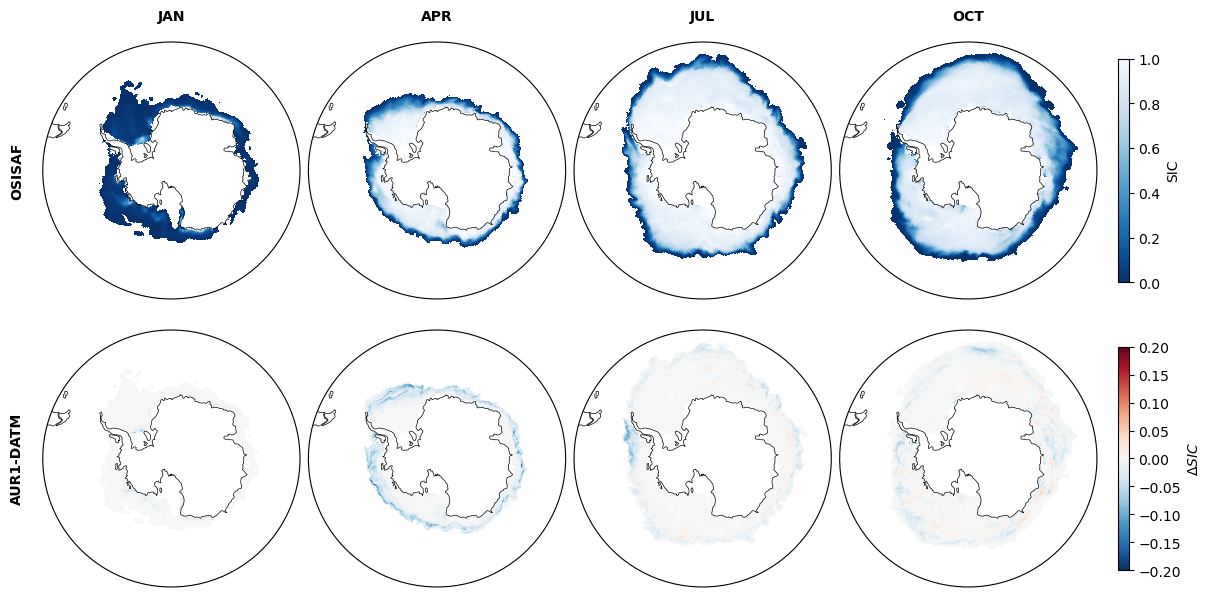

In [4]:
thold = 0.001

# Make circular boundary for polar stereographic circular plots
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# Create figure
proj  = ccrs.SouthPolarStereo()
fig, ax = plt.subplots(2, 4, figsize=(12, 6), layout='constrained', subplot_kw={'projection': proj})

icol = 0
for label, val in months.items():
    # Load datasets
    ds_datm_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_datm/ice_merged_35d_remap_bil_tmean.nc"))
    ds_aur1_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora/ice_merged_35d_remap_bil_tmean.nc"))

    # DATM
    data_datm_sh = ds_datm_mean.aice_d.isel(time=0)
    data_datm_sh = data_datm_sh.where(data_datm_sh > thold)
    im0 = data_datm_sh.plot(ax=ax[0,icol], transform=ccrs.PlateCarree(), vmin=0, vmax=1, cmap='Blues_r', add_colorbar=False)
    ax[0,icol].coastlines(linewidth=0.5)
    ax[0,icol].set_boundary(circle, transform=ax[0,icol].transAxes)
    ax[0,icol].set_extent([-180, 180, -50, -90], ccrs.PlateCarree())
    if icol == 3:
        fig.colorbar(im0, ax=ax[0,icol], pad=0.08, aspect=20, shrink=0.8, label='SIC')

    # AURORA 1W
    data_aur1_sh = ds_aur1_mean.aice_d.isel(time=0)
    data_aur1_sh = data_aur1_sh.where(data_aur1_sh > thold)
    data_aur1_sh_diff = data_aur1_sh-data_datm_sh
    im1 = data_aur1_sh_diff.plot(ax=ax[1,icol], transform=ccrs.PlateCarree(), vmin=-0.2, vmax=0.2, cmap='RdBu_r', add_colorbar=False)
    ax[1,icol].coastlines(linewidth=0.5)
    ax[1,icol].set_boundary(circle, transform=ax[1,icol].transAxes)
    ax[1,icol].set_extent([-180, 180, -50, -90], ccrs.PlateCarree())
    if icol == 3:
        fig.colorbar(im1, ax=ax[1,icol], pad=0.08, aspect=20, shrink=0.8, label=r'$\Delta SIC$')

    # Remove titles
    ax[0,icol].set_title("")
    ax[1,icol].set_title("")

    # Labels
    ax[0,icol].text(0.5, 1.1, f"{label}", transform=ax[0,icol].transAxes, ha='center', va='center', fontweight='bold', fontsize=10)
    if icol == 0:
        ax[0,icol].text(-0.1, 0.5, "OSISAF", transform=ax[0,icol].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)
        ax[1,icol].text(-0.1, 0.5, "AUR1-DATM", transform=ax[1,icol].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

    icol = icol+1

# Save to file
filename = "s2s_sic_SH_v2.png"
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)

Text(-0.1, 0.5, 'OCT')

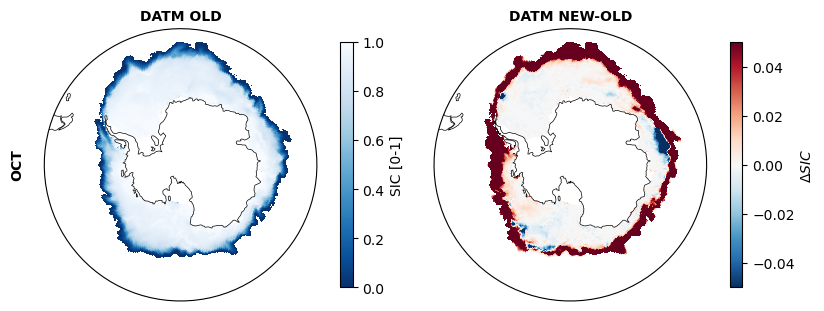

In [3]:
import matplotlib.path as mpath

thold = 0.001

# Make circular boundary for polar stereographic circular plots
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# Create figure
proj  = ccrs.SouthPolarStereo()
fig, ax = plt.subplots(1, 2, figsize=(8, 3), layout='constrained', subplot_kw={'projection': proj})

# Month
mm = 7
label = "OCT"

# Load datasets
#ds_aur1_mean = xr.open_dataset(os.path.join(data_path, f"2021{mm:02d}01_aurora/ice_merged_35d_remap_bil_tmean.nc"))
#ds_aur2_mean = xr.open_dataset(os.path.join(data_path, f"2021{mm:02d}01_aurora_two_way/ice_merged_35d_remap_bil_tmean.nc"))
ds_aur1_mean = xr.open_dataset(os.path.join(data_path, f"2021{mm:02d}01_datm/ice_merged_35d_remap_bil_tmean.nc"))
ds_aur2_mean = xr.open_dataset(os.path.join(data_path, f"2021{mm:02d}01_datm_test/ice_merged_35d_remap_bil_tmean.nc"))

# Aurora forced (1-way)
data_aur1_sh = ds_aur1_mean.aice_d.isel(time=0)
data_aur1_sh = data_aur1_sh.where(data_aur1_sh > thold)
im0 = data_aur1_sh.plot(ax=ax[0], transform=ccrs.PlateCarree(), vmin=0, vmax=1, cmap='Blues_r', add_colorbar=False)
ax[0].coastlines(linewidth=0.5)
ax[0].set_boundary(circle, transform=ax[0].transAxes)
ax[0].set_extent([-180, 180, -50, -90], ccrs.PlateCarree())
fig.colorbar(im0, ax=ax[0], pad=0.08, aspect=20, shrink=0.9, label='SIC [0-1]')

# Aurora forced (2-way)
data_aur2_sh = ds_aur2_mean.aice_d.isel(time=0)
data_aur2_sh = data_aur2_sh.where(data_aur2_sh > thold)
data_aur2_sh_diff = data_aur2_sh-data_aur1_sh
im1 = data_aur2_sh_diff.plot(ax=ax[1], transform=ccrs.PlateCarree(), vmin=-0.05, vmax=0.05, cmap='RdBu_r', add_colorbar=False)
ax[1].coastlines(linewidth=0.5)
ax[1].set_boundary(circle, transform=ax[1].transAxes)
ax[1].set_extent([-180, 180, -50, -90], ccrs.PlateCarree())
fig.colorbar(im1, ax=ax[1], pad=0.08, aspect=20, shrink=0.9, label=r'$\Delta SIC$')

# Labels
ax[0].set_title("DATM OLD", fontweight='bold', fontsize=10)
ax[1].set_title("DATM NEW-OLD", fontweight='bold', fontsize=10)
ax[0].text(-0.1, 0.5, f"{label}", transform=ax[0].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

JAN 1
APR 4
JUL 7
OCT 10


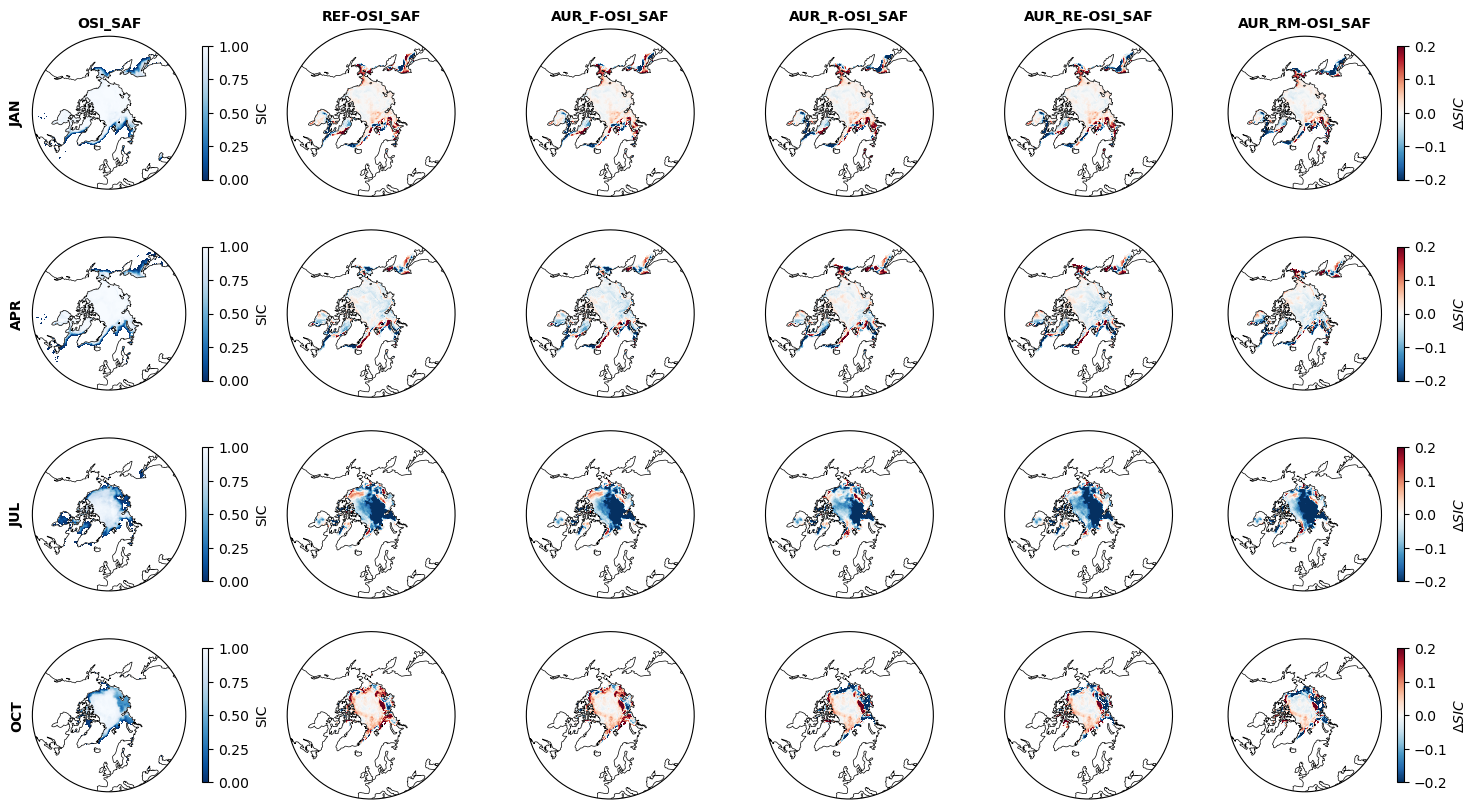

In [8]:
thold = 0.001

# Make circular boundary for polar stereographic circular plots
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# Create figure
proj  = ccrs.NorthPolarStereo()
fig, ax = plt.subplots(4, 6, figsize=(18, 10), subplot_kw={'projection': proj})

irow = 0
for label, val in months.items():
    print(label, val)
    # Load datasets
    ds_ice_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_seaice/seaice_N_35d_remap_bil_tmean.nc"))
    ds_datm_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_datm/ice_merged_35d_remap_bil_tmean.nc"))
    ds_aur1_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora/ice_merged_35d_remap_bil_tmean.nc"))
    ds_aur2_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_r2/ice_merged_35d_remap_bil_tmean.nc"))
    ds_aur3_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_r3/ice_merged_35d_remap_bil_tmean.nc"))
    ds_aur4_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_two_way_r4/ice_merged_35d_remap_bil_tmean.nc"))

    # OSISAF
    data_osisaf = ds_ice_mean.ice_conc.isel(time=0)
    data_osisaf = data_osisaf/100
    data_osisaf = data_osisaf.where(data_osisaf > thold)
    im0 = data_osisaf.plot(ax=ax[irow,0], transform=ccrs.PlateCarree(), vmin=0, vmax=1, cmap='Blues_r', add_colorbar=False)
    ax[irow,0].coastlines(linewidth=0.5)
    ax[irow,0].set_boundary(circle, transform=ax[irow,0].transAxes)
    ax[irow,0].set_extent([-180, 180, 40, 90], ccrs.PlateCarree())
    fig.colorbar(im0, ax=ax[irow,0], pad=0.08, aspect=20, shrink=0.8, label='SIC')

    # DATM
    data_datm_sh = ds_datm_mean.aice_d.isel(time=0)
    data_datm_sh = data_datm_sh.where(data_datm_sh > thold)
    data_datm_sh_diff = data_datm_sh-data_osisaf
    im1 = data_datm_sh_diff.plot(ax=ax[irow,1], transform=ccrs.PlateCarree(), vmin=-0.2, vmax=0.2, cmap='RdBu_r', add_colorbar=False)
    ax[irow,1].coastlines(linewidth=0.5)
    ax[irow,1].set_boundary(circle, transform=ax[irow,1].transAxes)
    ax[irow,1].set_extent([-180, 180, 40, 90], ccrs.PlateCarree())

    # AUR_F
    data_aur1_sh = ds_aur1_mean.aice_d.isel(time=0)
    data_aur1_sh = data_aur1_sh.where(data_aur1_sh > thold)
    data_aur1_sh_diff = data_aur1_sh-data_osisaf
    im2 = data_aur1_sh_diff.plot(ax=ax[irow,2], transform=ccrs.PlateCarree(), vmin=-0.2, vmax=0.2, cmap='RdBu_r', add_colorbar=False)
    ax[irow,2].coastlines(linewidth=0.5)
    ax[irow,2].set_boundary(circle, transform=ax[irow,2].transAxes)
    ax[irow,2].set_extent([-180, 180, 40, 90], ccrs.PlateCarree())

    # AUR_R
    data_aur2_sh = ds_aur2_mean.aice_d.isel(time=0)
    data_aur2_sh = data_aur2_sh.where(data_aur2_sh > thold)
    data_aur2_sh_diff = data_aur2_sh-data_osisaf
    im3 = data_aur2_sh_diff.plot(ax=ax[irow,3], transform=ccrs.PlateCarree(), vmin=-0.2, vmax=0.2, cmap='RdBu_r', add_colorbar=False)
    ax[irow,3].coastlines(linewidth=0.5)
    ax[irow,3].set_boundary(circle, transform=ax[irow,3].transAxes)
    ax[irow,3].set_extent([-180, 180, 40, 90], ccrs.PlateCarree())

    # AUR_RE
    data_aur3_sh = ds_aur3_mean.aice_d.isel(time=0)
    data_aur3_sh = data_aur3_sh.where(data_aur3_sh > thold)
    data_aur3_sh_diff = data_aur3_sh-data_osisaf
    im4 = data_aur3_sh_diff.plot(ax=ax[irow,4], transform=ccrs.PlateCarree(), vmin=-0.2, vmax=0.2, cmap='RdBu_r', add_colorbar=False)
    ax[irow,4].coastlines(linewidth=0.5)
    ax[irow,4].set_boundary(circle, transform=ax[irow,4].transAxes)
    ax[irow,4].set_extent([-180, 180, 40, 90], ccrs.PlateCarree())

    # AUR_RM
    data_aur4_sh = ds_aur4_mean.aice_d.isel(time=0)
    data_aur4_sh = data_aur4_sh.where(data_aur4_sh > thold)
    data_aur4_sh_diff = data_aur4_sh-data_osisaf
    im5 = data_aur4_sh_diff.plot(ax=ax[irow,5], transform=ccrs.PlateCarree(), vmin=-0.2, vmax=0.2, cmap='RdBu_r', add_colorbar=False)
    ax[irow,5].coastlines(linewidth=0.5)
    ax[irow,5].set_boundary(circle, transform=ax[irow,5].transAxes)
    ax[irow,5].set_extent([-180, 180, 40, 90], ccrs.PlateCarree())
    fig.colorbar(im5, ax=ax[irow,5], pad=0.08, aspect=20, shrink=0.8, label=r'$\Delta SIC$')

    # Labels
    if irow == 0:
        ax[irow,0].set_title("OSI_SAF", fontweight='bold', fontsize=10)
        ax[irow,1].set_title("REF-OSI_SAF", fontweight='bold', fontsize=10)
        ax[irow,2].set_title("AUR_F-OSI_SAF", fontweight='bold', fontsize=10)
        ax[irow,3].set_title("AUR_R-OSI_SAF", fontweight='bold', fontsize=10)
        ax[irow,4].set_title("AUR_RE-OSI_SAF", fontweight='bold', fontsize=10)
        ax[irow,5].set_title("AUR_RM-OSI_SAF", fontweight='bold', fontsize=10)
    else:
        ax[irow,0].set_title("")
        ax[irow,1].set_title("")
        ax[irow,2].set_title("")
        ax[irow,3].set_title("")
        ax[irow,4].set_title("")
        ax[irow,5].set_title("")

    ax[irow,0].text(-0.1, 0.5, f"{label}", transform=ax[irow,0].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

    irow = irow+1

# Save to file
filename = "s2s_sic_NH.png"
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)

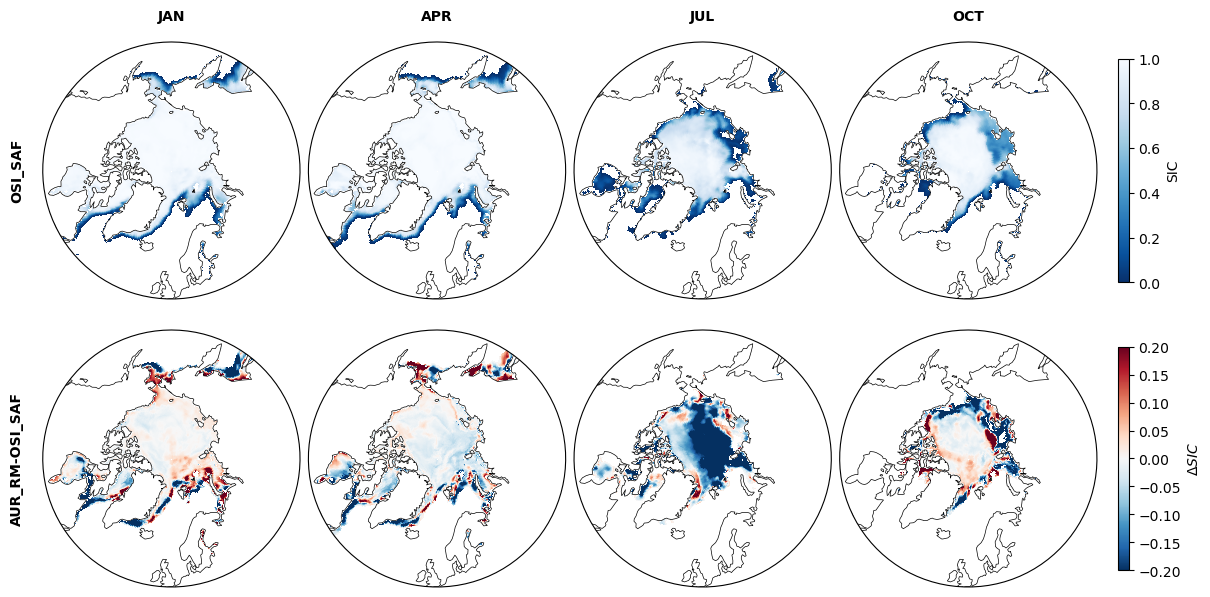

In [4]:
thold = 0.001

# Make circular boundary for polar stereographic circular plots
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# Create figure
proj  = ccrs.NorthPolarStereo()
fig, ax = plt.subplots(2, 4, figsize=(12, 6), layout='constrained', subplot_kw={'projection': proj})

icol = 0
for label, val in months.items():
    # Load datasets
    ds_ice_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_seaice/seaice_N_35d_remap_bil_tmean.nc"))
    ds_aur1_mean = xr.open_dataset(os.path.join(data_path, f"2021{val:02d}01_aurora_two_way_r4/ice_merged_35d_remap_bil_tmean.nc"))

    # OSISAF
    data_osisaf = ds_ice_mean.ice_conc.isel(time=0)
    data_osisaf = data_osisaf/100
    data_osisaf = data_osisaf.where(data_osisaf > thold)
    im0 = data_osisaf.plot(ax=ax[0,icol], transform=ccrs.PlateCarree(), vmin=0, vmax=1, cmap='Blues_r', add_colorbar=False)
    ax[0,icol].coastlines(linewidth=0.5)
    ax[0,icol].set_boundary(circle, transform=ax[0,icol].transAxes)
    ax[0,icol].set_extent([-180, 180, 50, 90], ccrs.PlateCarree())
    if icol == 3:
        fig.colorbar(im0, ax=ax[0,icol], pad=0.08, aspect=20, shrink=0.8, label='SIC')

    # AURORA 1W
    data_aur1_sh = ds_aur1_mean.aice_d.isel(time=0)
    data_aur1_sh = data_aur1_sh.where(data_aur1_sh > thold)
    data_aur1_sh_diff = data_aur1_sh-data_osisaf
    im1 = data_aur1_sh_diff.plot(ax=ax[1,icol], transform=ccrs.PlateCarree(), vmin=-0.2, vmax=0.2, cmap='RdBu_r', add_colorbar=False)
    ax[1,icol].coastlines(linewidth=0.5)
    ax[1,icol].set_boundary(circle, transform=ax[1,icol].transAxes)
    ax[1,icol].set_extent([-180, 180, 50, 90], ccrs.PlateCarree())
    if icol == 3:
        fig.colorbar(im1, ax=ax[1,icol], pad=0.08, aspect=20, shrink=0.8, label=r'$\Delta SIC$')

    # Remove titles
    ax[0,icol].set_title("")
    ax[1,icol].set_title("")

    # Labels
    ax[0,icol].text(0.5, 1.1, f"{label}", transform=ax[0,icol].transAxes, ha='center', va='center', fontweight='bold', fontsize=10)
    if icol == 0:
        ax[0,icol].text(-0.1, 0.5, "OSI_SAF", transform=ax[0,icol].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)
        ax[1,icol].text(-0.1, 0.5, "AUR_RM-OSI_SAF", transform=ax[1,icol].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

    icol = icol+1

# Save to file
filename = "s2s_sic_NH_v2.png"
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)